In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set general style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# Define the 3-way color palette to keep colors consistent across charts
palette_3way = {
    'Transformer': '#1b9e77', 
    'XGBoost Baseline': '#7570b3', 
    'Persistence Baseline': '#d95f02'
}

# Load all required CSV data
df_trans_season = pd.read_csv('discharge_metrics_by_season.csv')
df_xgb_season = pd.read_csv('discharge_xgboost_metrics_by_season.csv')
df_trans_horizon = pd.read_csv('discharge_metrics_by_season_horizon.csv')
df_xgb_horizon = pd.read_csv('discharge_xgboost_metrics_by_season_horizon.csv')
df_trans_overall = pd.read_csv('discharge_overall_validation_metrics.csv')
df_xgb_overall = pd.read_csv('discharge_xgboost_overall_validation_metrics.csv')

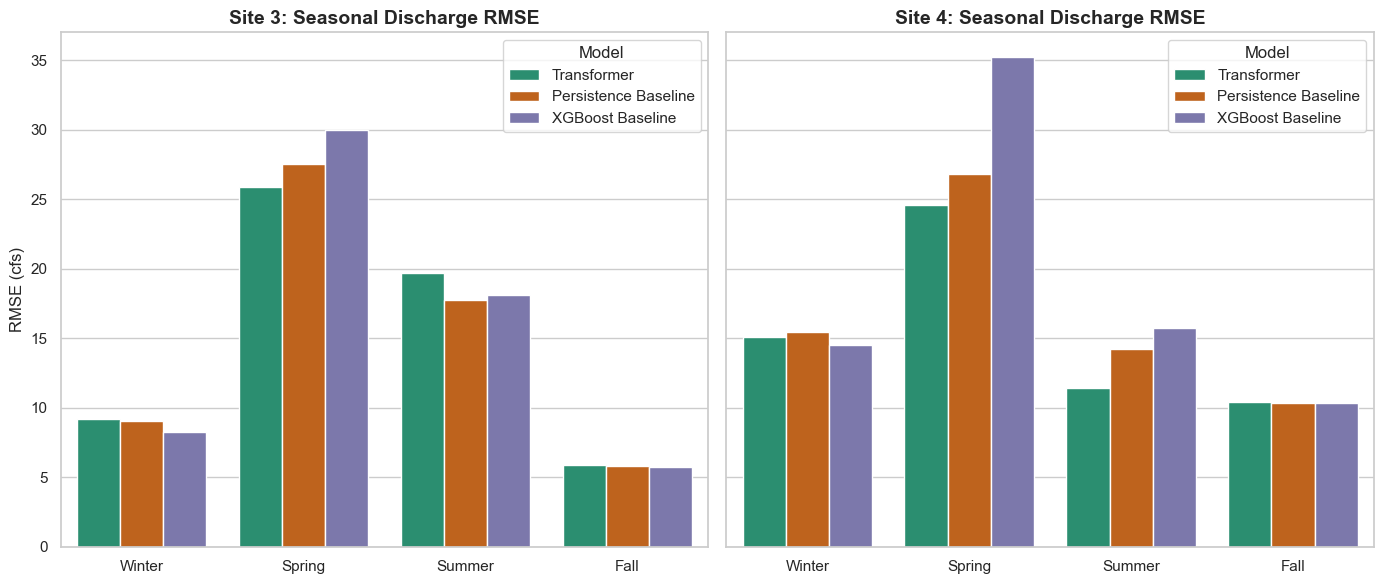

In [3]:
records = []

# Extract Transformer and Persistence Data
for _, row in df_trans_season.iterrows():
    site = f"Site {int(row['site_id'])}"
    season = str(row['season']).capitalize()
    records.append({'Site': site, 'Season': season, 'Model': 'Transformer', 'RMSE': row['rmse']})
    records.append({'Site': site, 'Season': season, 'Model': 'Persistence Baseline', 'RMSE': row['persistence_rmse']})
    
# Extract XGBoost Data
for _, row in df_xgb_season.iterrows():
    site = f"Site {int(row['site_id'])}"
    season = str(row['season']).capitalize()
    records.append({'Site': site, 'Season': season, 'Model': 'XGBoost Baseline', 'RMSE': row['rmse']})

df_seasonal = pd.DataFrame(records)

# Order seasons chronologically
df_seasonal['Season'] = pd.Categorical(df_seasonal['Season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)

# Plot the charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(data=df_seasonal[df_seasonal['Site'] == 'Site 3'], x='Season', y='RMSE', hue='Model', ax=axes[0], palette=palette_3way)
axes[0].set_title('Site 3: Seasonal Discharge RMSE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE (cfs)', fontsize=12)
axes[0].set_xlabel('')

sns.barplot(data=df_seasonal[df_seasonal['Site'] == 'Site 4'], x='Season', y='RMSE', hue='Model', ax=axes[1], palette=palette_3way)
axes[1].set_title('Site 4: Seasonal Discharge RMSE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

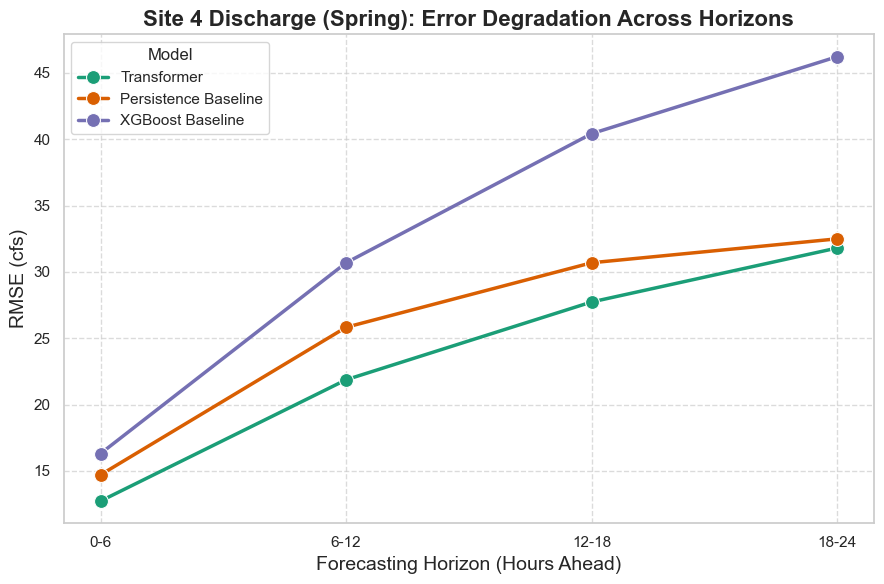

In [4]:
# Filter data for Site 4, Spring only
df_trans_h_spring = df_trans_horizon[(df_trans_horizon['site_id'] == 4) & (df_trans_horizon['season'] == 'spring')]
df_xgb_h_spring = df_xgb_horizon[(df_xgb_horizon['site_id'] == 4) & (df_xgb_horizon['season'] == 'spring')]

h_records = []

# Extract Transformer and Persistence Data
for _, row in df_trans_h_spring.iterrows():
    h_records.append({'Horizon': row['horizon_bin'], 'Model': 'Transformer', 'RMSE': row['rmse']})
    h_records.append({'Horizon': row['horizon_bin'], 'Model': 'Persistence Baseline', 'RMSE': row['persistence_rmse']})

# Extract XGBoost Data
for _, row in df_xgb_h_spring.iterrows():
    h_records.append({'Horizon': row['horizon_bin'], 'Model': 'XGBoost Baseline', 'RMSE': row['rmse']})

df_horizon_plot = pd.DataFrame(h_records)

# Plot the chart
plt.figure(figsize=(9, 6))
sns.lineplot(data=df_horizon_plot, x='Horizon', y='RMSE', hue='Model', marker='o', linewidth=2.5, markersize=10, palette=palette_3way)
plt.title('Site 4 Discharge (Spring): Error Degradation Across Horizons', fontsize=16, fontweight='bold')
plt.ylabel('RMSE (cfs)', fontsize=14)
plt.xlabel('Forecasting Horizon (Hours Ahead)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

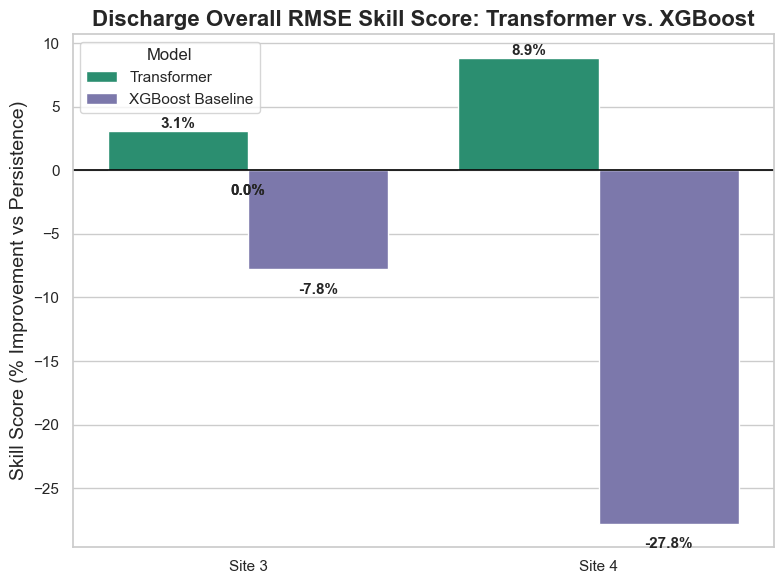

In [5]:
skill_records = []

# Extract Transformer Skill Score (Converting to Percentage)
for _, row in df_trans_overall.iterrows():
    site = f"Site {int(row['site_id'])}"
    skill_records.append({'Site': site, 'Model': 'Transformer', 'RMSE Skill Score (%)': row['rmse_skill_vs_persistence'] * 100})

# Extract XGBoost Skill Score (Converting to Percentage)
for _, row in df_xgb_overall.iterrows():
    site = f"Site {int(row['site_id'])}"
    skill_records.append({'Site': site, 'Model': 'XGBoost Baseline', 'RMSE Skill Score (%)': row['rmse_skill_vs_persistence'] * 100})

df_skill_plot = pd.DataFrame(skill_records)

# Plot the chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=df_skill_plot, x='Site', y='RMSE Skill Score (%)', hue='Model', palette={'Transformer': '#1b9e77', 'XGBoost Baseline': '#7570b3'})
plt.title('Discharge Overall RMSE Skill Score: Transformer vs. XGBoost', fontsize=16, fontweight='bold')
plt.ylabel('Skill Score (% Improvement vs Persistence)', fontsize=14)
plt.xlabel('')
plt.axhline(0, color='black', linewidth=1.2)

# Add value labels dynamically handling positive and negative offsets
for p in ax.patches:
    val = p.get_height()
    y_offset = 5 if val > 0 else -15
    ax.annotate(f"{val:.1f}%", 
                 (p.get_x() + p.get_width() / 2., val), 
                 ha = 'center', va = 'center', 
                 xytext = (0, y_offset), 
                 textcoords = 'offset points',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

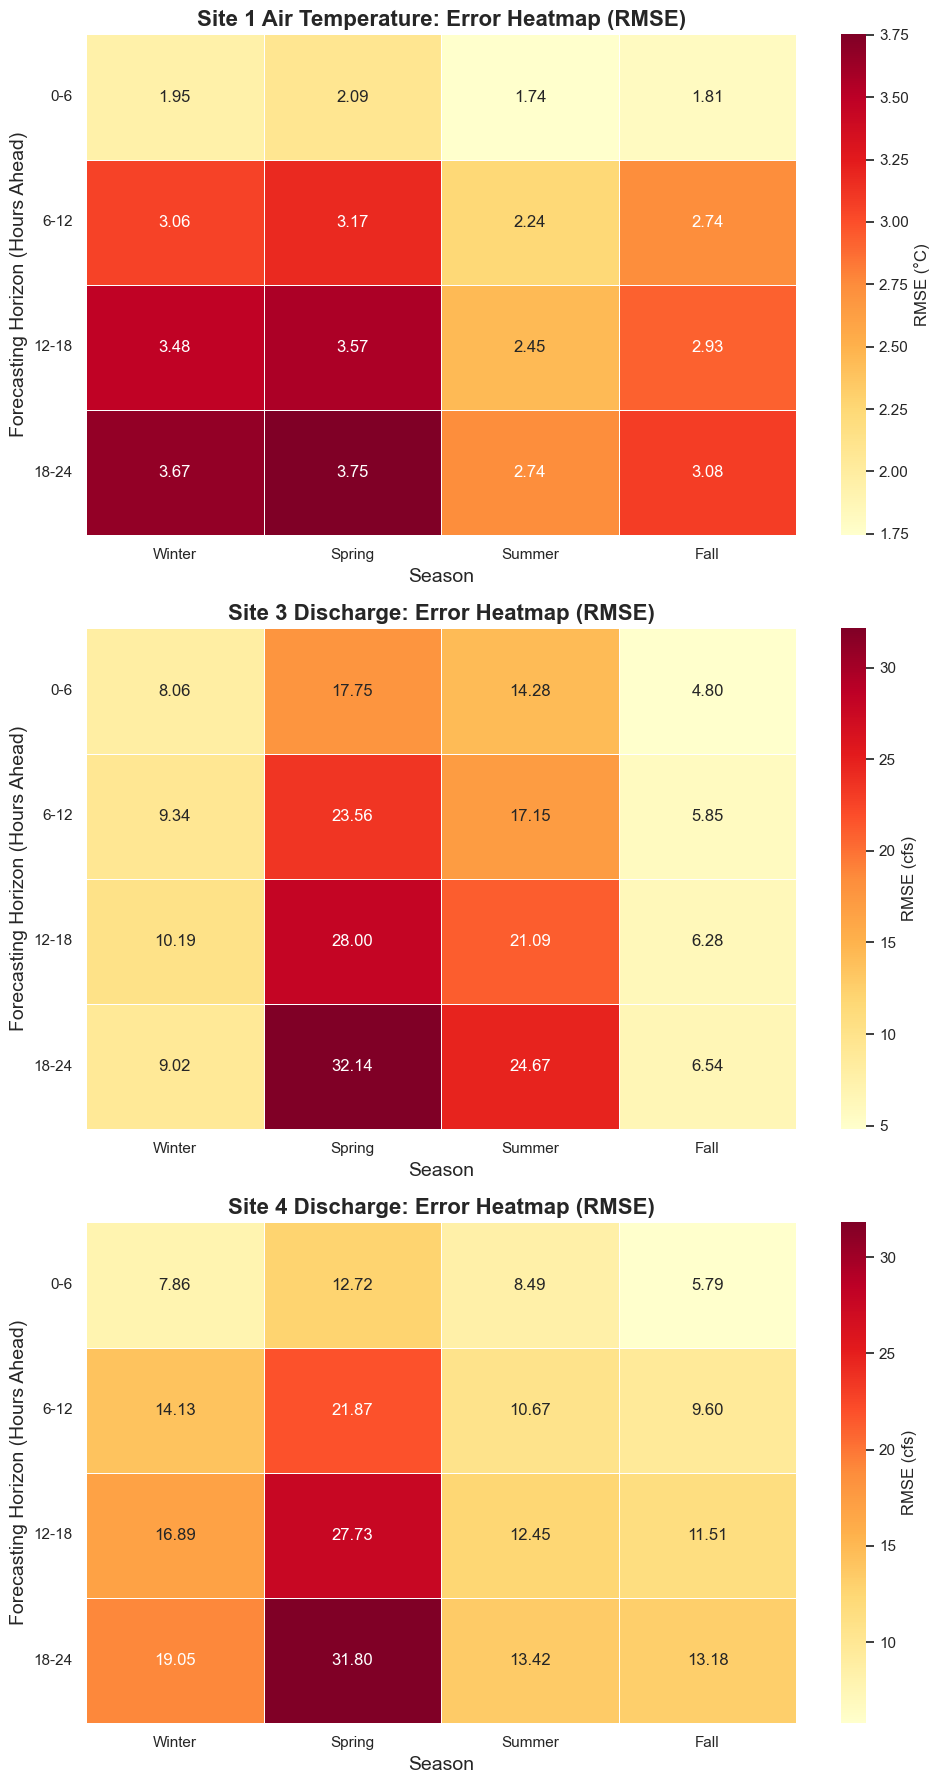

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Load the Transformer horizon metrics
df_air_h = pd.read_csv('air_temperature_metrics_by_season_horizon.csv')
df_dis_h = pd.read_csv('discharge_metrics_by_season_horizon.csv')

# Combine the data for the available sites
sites_to_plot = []
if 1 in df_air_h['site_id'].values: sites_to_plot.append((df_air_h, 1, "Air Temperature (°C)"))
# if 2 in df_air_h['site_id'].values: sites_to_plot.append((df_air_h, 2, "Air Temperature (°C)"))
if 3 in df_dis_h['site_id'].values: sites_to_plot.append((df_dis_h, 3, "Discharge (cfs)"))
if 4 in df_dis_h['site_id'].values: sites_to_plot.append((df_dis_h, 4, "Discharge (cfs)"))

# Create plots
fig, axes = plt.subplots(len(sites_to_plot), 1, figsize=(10, 6 * len(sites_to_plot)))
if len(sites_to_plot) == 1:
    axes = [axes]
    
for ax, (df, site, var_name) in zip(axes, sites_to_plot):
    # Filter for the specific site
    df_site = df[df['site_id'] == site].copy()
    df_site['Season'] = df_site['season'].str.capitalize()
    
    # Pivot the dataframe to create the requested matrix 
    # (Rows: Horizon, Columns: Season)
    df_heat = df_site.pivot(index='horizon_bin', columns='Season', values='rmse')
    
    # Order the rows and columns logically
    df_heat = df_heat[['Winter', 'Spring', 'Summer', 'Fall']]
    df_heat = df_heat.reindex(['0-6', '6-12', '12-18', '18-24'])
    
    # Plot the heatmap
    sns.heatmap(
        df_heat, 
        annot=True, 
        fmt=".2f", 
        cmap="YlOrRd", 
        linewidths=.5, 
        ax=ax, 
        cbar_kws={'label': f'RMSE ({var_name.split()[-1][1:-1]})'} # Extracts unit dynamically
    )
    
    # Labeling
    var_title = var_name.split(' (')[0] # E.g., 'Air Temperature' or 'Discharge'
    ax.set_title(f'Site {site} {var_title}: Error Heatmap (RMSE)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Season', fontsize=14)
    ax.set_ylabel('Forecasting Horizon (Hours Ahead)', fontsize=14)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()